Active Compute Device: cuda
GPU Name: Tesla T4
Monument vector geometry distribution:
Polygon    1182
Name: count, dtype: int64

Indexing dataset files...
Train Patches: 2,533 | Val: 584 | Test: 500

--- Checking Raster/Vector Alignment (20 site patches) ---
Empty Mask Rate: 0/20 (0.0%)
✓ Alignment check passed.
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 98.2MB/s]



  Training Pipeline | Validation-Driven Checkpointing | Epochs: 20
Ep 01/20 | LR: 1.99e-04  ✓ saved | no_improve: 0/5
  Train -> Loss: 0.1495 | AUC: 0.5340 | F1: 0.4037 | Prec: 0.4369 | Rec: 0.3751
  Val   -> Loss: 0.1362 | AUC: 0.6100 | F1: 0.4715 | Prec: 0.3683 | Rec: 0.6554
Ep 02/20 | LR: 1.95e-04  ✓ saved | no_improve: 0/5
  Train -> Loss: 0.1328 | AUC: 0.5769 | F1: 0.4044 | Prec: 0.4574 | Rec: 0.3625
  Val   -> Loss: 0.1181 | AUC: 0.6631 | F1: 0.4632 | Prec: 0.4335 | Rec: 0.4972
Ep 03/20 | LR: 1.89e-04  ✓ saved | no_improve: 0/5
  Train -> Loss: 0.1200 | AUC: 0.6244 | F1: 0.4460 | Prec: 0.5065 | Rec: 0.3984
  Val   -> Loss: 0.1067 | AUC: 0.6870 | F1: 0.4665 | Prec: 0.5368 | Rec: 0.4124
Ep 04/20 | LR: 1.81e-04 | no_improve: 1/5
  Train -> Loss: 0.1155 | AUC: 0.6278 | F1: 0.4945 | Prec: 0.5441 | Rec: 0.4531
  Val   -> Loss: 0.1062 | AUC: 0.6863 | F1: 0.5257 | Prec: 0.5052 | Rec: 0.5480
Ep 05/20 | LR: 1.71e-04 | no_improve: 2/5
  Train -> Loss: 0.1092 | AUC: 0.6483 | F1: 0.4684 | Pr

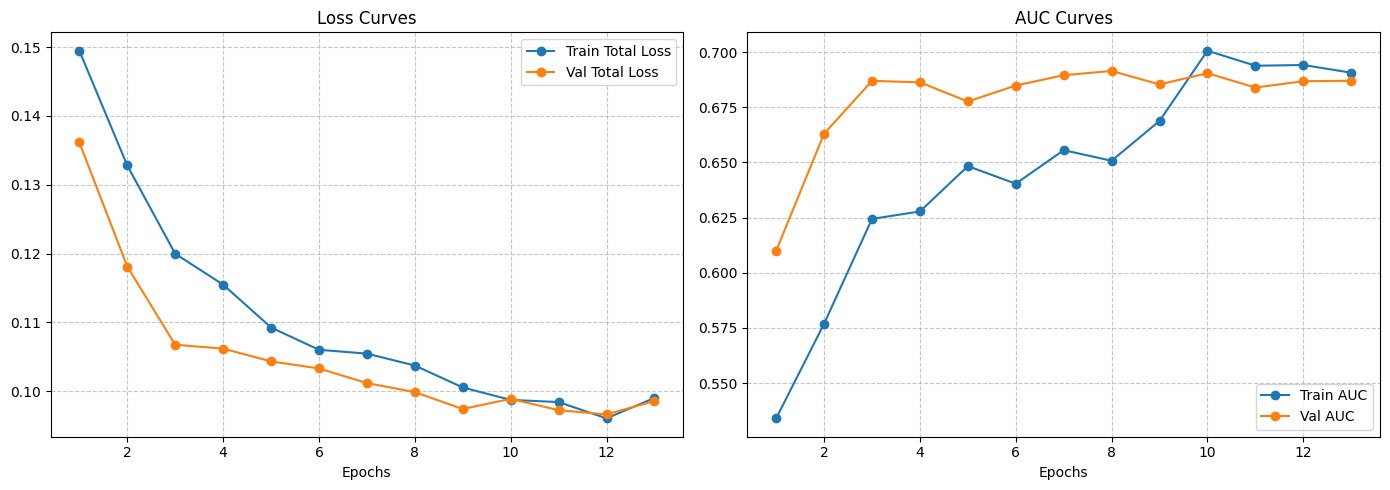


Loading best checkpoint from: mobilenet_v3_small_lidar_best.pth

VAL CALIBRATION -> Best Threshold: 0.5044 (Val F1: 0.5510, Val AUC: 0.6915)
UNTOUCHED TEST PERFORMANCE (AUC: 0.6481):
Test @ Default Cutoff (Threshold: 0.5000):
  • F1 Score  : 0.4411
  • Precision : 0.4033
  • Recall    : 0.4867
Test @ Val-Calibrated Cutoff (Threshold: 0.5044):
  • F1 Score  : 0.4479
  • Precision : 0.4148
  • Recall    : 0.4867

Visualizing Top 3 Worst False Negatives:


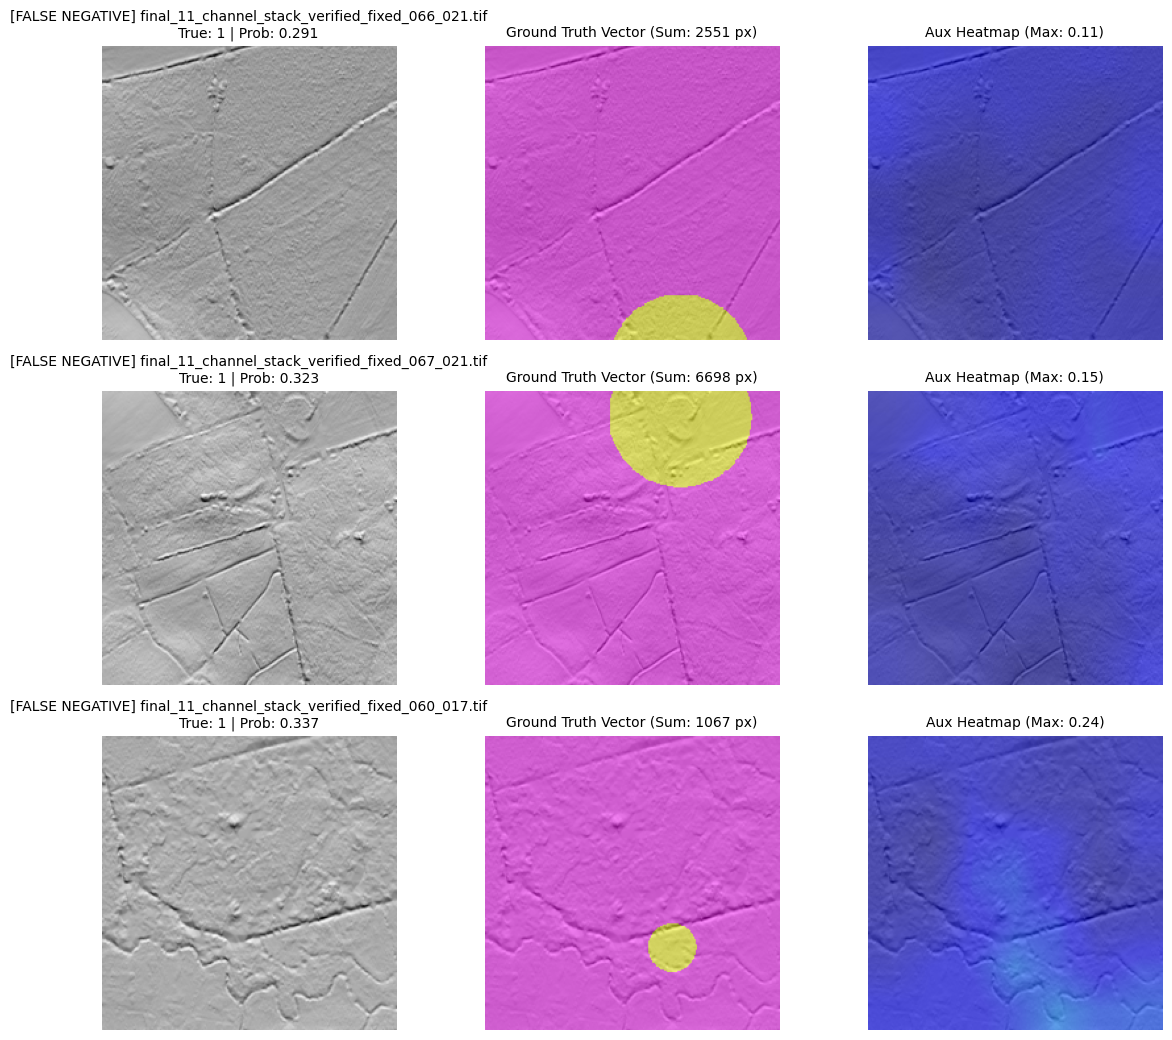


Visualizing Top 3 Worst False Positives:


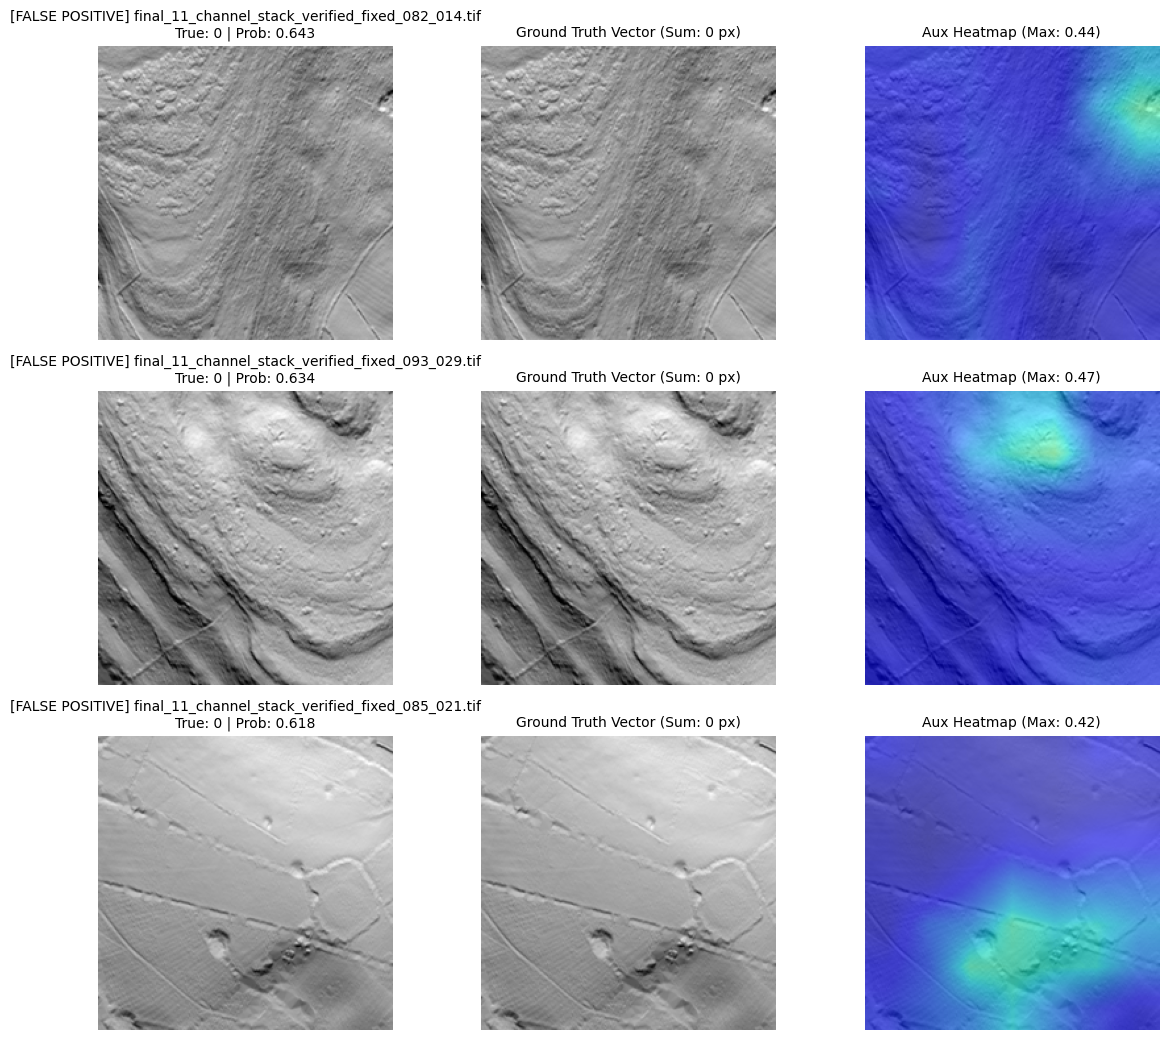

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. ENVIRONMENT SETUP & DEPENDENCIES
# ══════════════════════════════════════════════════════════════════════════════
# In a Kaggle Notebook, run this in a top cell or keep it uncommented:
# !pip install -q rasterio geopandas shapely pyproj

import os
import gc
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.models as models
import torchvision.transforms.functional as TF

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve
)

import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import pyproj
from shapely.geometry import box

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Active Compute Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')

torch.backends.cudnn.benchmark = True

# ══════════════════════════════════════════════════════════════════════════════
# 2. CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    ROOT                 = Path('/kaggle/input/datasets/shreyansdeshpande/2nd-variation/FINALCNNDATA_NEW_01')
    OUTPUT_DIR           = Path('/kaggle/working')
    MONUMENT_VECTOR_PATH = Path('/kaggle/input/datasets/shreyansdeshpande/monuments/monuments_inside_valid_dtm.gpkg')
    
    TRAIN_SITE    = ROOT / 'train' / 'site'
    TRAIN_NOSITE  = ROOT / 'train' / 'no_site'
    VAL_SITE      = ROOT / 'validation' / 'site'
    VAL_NOSITE    = ROOT / 'validation' / 'no_site'
    TEST_SITE     = ROOT / 'test' / 'site'
    TEST_NOSITE   = ROOT / 'test' / 'no_site'
    
    IMG_SUFFIX    = '.tif'
    
    # 7 Pure LiDAR Channels: SVF (4), LRM (5), Slope (6), HS0-HS3 (7-10)
    LIDAR_BANDS   = list(range(4, 11))   
    NUM_LIDAR_CH  = 7                        

    NUM_CLASSES       = 1
    PRETRAINED        = True
    FREEZE_BACKBONES  = True  
    UNFREEZE_BLOCKS   = 2            # Unfreeze only the last 2 InvertedResidual blocks
    
    USE_MIXUP         = False        # Preserves micro-relief and clean binary masks
    MIXUP_ALPHA       = 0.3
    
    DROPOUT                = 0.5          
    LR                     = 2e-4         
    HEAD_WEIGHT_DECAY      = 2e-3    
    BACKBONE_WEIGHT_DECAY  = 1e-2    # 5x higher decay on unfrozen backbone
    MASK_WEIGHT            = 0.1          
    
    OVERSAMPLE_POWER       = 0.5     # Softened square-root reweighting

    IMG_SIZE     = 224
    BATCH_SIZE   = 32
    NUM_EPOCHS   = 20
    PATIENCE     = 5
    SEED         = 42
    NUM_WORKERS  = 2                 # 2 is optimal on Kaggle (prevents /dev/shm exhaustion)
    USE_AMP      = True              

    T_MAX   = NUM_EPOCHS
    ETA_MIN = 1e-6

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# 3. VECTOR MONUMENT PROCESSING & ROBUST BUFFERING
# ══════════════════════════════════════════════════════════════════════════════
if not CFG.MONUMENT_VECTOR_PATH.exists():
    raise FileNotFoundError(f"Monument vector file not found at: {CFG.MONUMENT_VECTOR_PATH}")

monuments_gdf = gpd.read_file(CFG.MONUMENT_VECTOR_PATH)
if monuments_gdf.crs is None:
    raise ValueError(f"Vector dataset {CFG.MONUMENT_VECTOR_PATH} has no embedded CRS.")

print("Monument vector geometry distribution:")
print(monuments_gdf.geometry.geom_type.value_counts())

is_point_geom = monuments_gdf.geometry.geom_type.isin(['Point', 'MultiPoint'])
if is_point_geom.any():
    monuments_gdf.loc[is_point_geom, 'geometry'] = monuments_gdf.loc[is_point_geom, 'geometry'].buffer(15)
    print(f"Buffered {is_point_geom.sum()} point markers by 15 meters.")

_CRS_CACHE = {}

def get_reprojected_monuments(target_crs):
    target_pyproj = pyproj.CRS.from_user_input(target_crs)
    gdf_pyproj = monuments_gdf.crs if isinstance(monuments_gdf.crs, pyproj.CRS) else pyproj.CRS.from_user_input(monuments_gdf.crs)

    target_epsg = target_pyproj.to_epsg()
    gdf_epsg = gdf_pyproj.to_epsg()

    if target_epsg is not None and gdf_epsg is not None:
        is_same_crs = (target_epsg == gdf_epsg)
    else:
        is_same_crs = (target_pyproj.to_wkt() == gdf_pyproj.to_wkt())

    crs_key = target_pyproj.to_string()
    if crs_key not in _CRS_CACHE:
        if is_same_crs:
            reproj = monuments_gdf
        else:
            reproj = monuments_gdf.to_crs(target_pyproj)
        _CRS_CACHE[crs_key] = (reproj, reproj.sindex)
    return _CRS_CACHE[crs_key]

# ══════════════════════════════════════════════════════════════════════════════
# 4. LOSS FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ls    = label_smoothing
        self.bce   = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        targets = targets * (1.0 - self.ls) + 0.5 * self.ls
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        return (alpha_t * (1.0 - pt) ** self.gamma * bce_loss).mean()

focal_criterion = BinaryFocalLoss(alpha=0.5, gamma=2.0, label_smoothing=0.1)
mask_criterion  = nn.BCEWithLogitsLoss()

def combined_loss(class_logits, mask_logits, class_targets, mask_targets):
    cls_loss = focal_criterion(class_logits, class_targets)
    
    b, c, h, w = mask_logits.shape
    mask_targets_down = F.interpolate(
        mask_targets.unsqueeze(1), 
        size=(h, w), 
        mode='bilinear', 
        align_corners=False
    )
    
    msk_loss = mask_criterion(mask_logits, mask_targets_down)
    total_loss = cls_loss + (CFG.MASK_WEIGHT * msk_loss)
    return total_loss, cls_loss, msk_loss

# ══════════════════════════════════════════════════════════════════════════════
# 5. DATA SCANNING & ALIGNMENT DIAGNOSTICS
# ══════════════════════════════════════════════════════════════════════════════
def folder_to_df(site_dir: Path, nosite_dir: Path) -> pd.DataFrame:
    rows = []
    for label, folder in [(1, site_dir), (0, nosite_dir)]:
        files = list(folder.glob(f'*{CFG.IMG_SUFFIX}'))
        for f in sorted(files):
            rows.append({'filepath': str(f), 'label': label})
    return pd.DataFrame(rows, columns=['filepath', 'label'])

print('\nIndexing dataset files...')
train_df = folder_to_df(CFG.TRAIN_SITE, CFG.TRAIN_NOSITE)
val_df   = folder_to_df(CFG.VAL_SITE,   CFG.VAL_NOSITE)
test_df  = folder_to_df(CFG.TEST_SITE,  CFG.TEST_NOSITE)

print(f'Train Patches: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
if len(train_df) == 0: raise FileNotFoundError("Train DataFrame is empty! Verify CFG.ROOT.")
if len(val_df) == 0:   raise FileNotFoundError("Val DataFrame is empty! Verify CFG.ROOT.")
if len(test_df) == 0:  raise FileNotFoundError("Test DataFrame is empty! Verify CFG.ROOT.")

def per_channel_normalize(arr: np.ndarray) -> np.ndarray:
    mean = arr.mean(axis=(1, 2), keepdims=True)
    std = arr.std(axis=(1, 2), keepdims=True)
    std = np.where(std < 1e-3, 1.0, std)
    return (arr - mean) / (std + 1e-6)

def load_patch_and_mask(tif_path: str, label: int, warn_empty: bool = False) -> tuple:
    with rasterio.open(tif_path) as src:
        img = src.read().astype(np.float32)
        crs = src.crs
        transform = src.transform
        bounds = src.bounds
        h, w = src.height, src.width

    if label == 0:
        return img, np.zeros((h, w), dtype=np.float32)

    reproj_gdf, sindex = get_reprojected_monuments(crs)
    patch_box = box(*bounds)
    possible_matches_idx = list(sindex.intersection(bounds))

    if possible_matches_idx:
        possible_matches = reproj_gdf.iloc[possible_matches_idx]
        exact_matches = possible_matches[possible_matches.intersects(patch_box)]

        if not exact_matches.empty:
            shapes = [(geom, 1) for geom in exact_matches.geometry if geom is not None and not geom.is_empty]
            mask = rasterize(
                shapes,
                out_shape=(h, w),
                transform=transform,
                fill=0,
                all_touched=True,
                dtype=np.float32
            )
            return img, mask

    if warn_empty:
        warnings.warn(f"Site patch (label=1) has 0 intersecting polygons: {tif_path}")

    return img, np.zeros((h, w), dtype=np.float32)

# Quick sanity check
def run_alignment_diagnostic(df: pd.DataFrame, num_samples: int = 20):
    print(f"\n--- Checking Raster/Vector Alignment ({num_samples} site patches) ---")
    site_patches = df[df['label'] == 1].sample(min(num_samples, len(df[df['label'] == 1])), random_state=CFG.SEED)
    empty_patches = [row['filepath'] for _, row in site_patches.iterrows() if load_patch_and_mask(row['filepath'], 1)[1].sum() == 0]
    empty_rate = len(empty_patches) / len(site_patches)
    print(f"Empty Mask Rate: {len(empty_patches)}/{len(site_patches)} ({empty_rate:.1%})")
    if empty_rate > 0.3:
        warnings.warn("High empty mask rate detected! Verify raster and vector extent overlap.")
    else:
        print("✓ Alignment check passed.")

run_alignment_diagnostic(train_df, num_samples=20)

# ══════════════════════════════════════════════════════════════════════════════
# 6. PYTORCH DATASET & DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════
class ArchSiteDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train: bool = True):
        self.df       = df.reset_index(drop=True)
        self.is_train = is_train
        
    def __len__(self): 
        return len(self.df)
    
    def _augment(self, t):
        if random.random() > 0.5: t = TF.hflip(t)
        if random.random() > 0.5: t = TF.vflip(t)
        angle = random.choice([0, 90, 180, 270])
        if angle: t = TF.rotate(t, angle)

        if random.random() > 0.5:
            t = TF.rotate(t, random.uniform(-20, 20))

        # Apply noise/cutout/dropout solely to imagery channels (preserve t[-1] mask)
        if random.random() > 0.4:
            t[:-1] = t[:-1] + torch.randn_like(t[:-1]) * random.uniform(0.01, 0.05)

        if random.random() > 0.5:
            _, h, w = t.shape
            eh = random.randint(h // 10, h // 4)
            ew = random.randint(w // 10, w // 4)
            y  = random.randint(0, h - eh)
            x  = random.randint(0, w - ew)
            t[:-1, y:y+eh, x:x+ew] = 0.0

        if random.random() > 0.5:
            t[random.randint(0, t.shape[0] - 2)] = 0.0

        return t
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img, mask_np = load_patch_and_mask(row['filepath'], int(row['label']), warn_empty=False)
        
        t_img = torch.from_numpy(per_channel_normalize(img))
        t_img = TF.resize(t_img, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        
        mask_t = torch.from_numpy(mask_np).unsqueeze(0)
        mask_t = TF.resize(mask_t, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.NEAREST)
        mask_t = (mask_t > 0.5).float()
        
        t_bands = t_img[CFG.LIDAR_BANDS]
        t_combined = torch.cat([t_bands, mask_t], dim=0)
        
        if self.is_train:
            t_combined = self._augment(t_combined)
            
        mask_aug = t_combined[-1] 
        t_img_final = t_combined[:-1]   
        
        return t_img_final, mask_aug, torch.tensor(row['label'], dtype=torch.float32)

class_counts = train_df['label'].value_counts().to_dict()
n_nosite = class_counts.get(0, 1)
n_site = class_counts.get(1, 1)

class_weights = {
    0: (1.0 / n_nosite) ** CFG.OVERSAMPLE_POWER,
    1: (1.0 / n_site) ** CFG.OVERSAMPLE_POWER
}
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)

trn_loader = DataLoader(
    ArchSiteDataset(train_df, is_train=True),
    batch_size=CFG.BATCH_SIZE,
    sampler=sampler, 
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True if CFG.NUM_WORKERS > 0 else False,
    drop_last=True
)

val_loader = DataLoader(
    ArchSiteDataset(val_df, is_train=False),
    batch_size=CFG.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True if CFG.NUM_WORKERS > 0 else False
)

test_loader = DataLoader(
    ArchSiteDataset(test_df, is_train=False),
    batch_size=CFG.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

# ══════════════════════════════════════════════════════════════════════════════
# 7. MODEL ARCHITECTURE (MOBILENETV3-SMALL + AUX HEAD)
# ══════════════════════════════════════════════════════════════════════════════
class LiDARMobileNetV3WithAux(nn.Module):
    def __init__(self, in_channels=7, num_classes=1, pretrained=True, dropout=0.5):
        super().__init__()
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.mobilenet_v3_small(weights=weights)

        old_conv = backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=False
        )
        
        if pretrained:
            with torch.no_grad():
                old_w = old_conv.weight
                rgb_mean = old_w.mean(dim=1, keepdim=True)
                new_w = torch.zeros(old_w.shape[0], in_channels, *old_w.shape[2:])

                # Custom LiDAR derivative initialization
                new_w[:, 0:1, :, :] = rgb_mean * 0.7  # SVF
                new_w[:, 1:2, :, :] = rgb_mean * 0.3  # LRM
                nn.init.kaiming_normal_(new_w[:, 2:3, :, :], mode='fan_out') # Slope
                new_w[:, 2:3, :, :] *= 0.1
                new_w[:, 3:7, :, :] = rgb_mean.repeat(1, 4, 1, 1)            # HS0-HS3

                new_conv.weight.copy_(new_w)

        backbone.features[0][0] = new_conv

        for p in backbone.parameters():
            p.requires_grad = False

        # Unfreeze input layer
        for p in backbone.features[0][0].parameters():
            p.requires_grad = True
            
        # Unfreeze last N blocks
        for block in backbone.features[-CFG.UNFREEZE_BLOCKS:]:
            for p in block.parameters():
                p.requires_grad = True

        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(576, num_classes)
        )

        self.mask_head = nn.Sequential(
            nn.Conv2d(96, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.3),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        spatial_feat = None
        for i, layer in enumerate(self.features):
            x = layer(x)
            if i == len(self.features) - 2:
                spatial_feat = x

        pooled = self.pool(x).flatten(1)
        class_logits = self.classifier(pooled)
        mask_logits = self.mask_head(spatial_feat)
        return class_logits, mask_logits

def get_model():
    return LiDARMobileNetV3WithAux(
        in_channels=CFG.NUM_LIDAR_CH,
        num_classes=CFG.NUM_CLASSES,
        pretrained=CFG.PRETRAINED,
        dropout=CFG.DROPOUT
    ).to(DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# 8. TRAINING & VALIDATION LOOPS
# ══════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss, total_cls_loss, total_msk_loss = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []
    
    for lidar, mask_targets, labels in loader:
        lidar = lidar.to(DEVICE, non_blocking=True)
        mask_targets = mask_targets.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.USE_AMP):
            class_logits, mask_logits = model(lidar)
            loss, cls_loss, msk_loss = combined_loss(class_logits.squeeze(1), mask_logits, labels, mask_targets)
            
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_cls_loss += cls_loss.item() * batch_size
        total_msk_loss += msk_loss.item() * batch_size
        
        preds = torch.sigmoid(class_logits).squeeze(1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    
    f1 = f1_score(all_labels, bin_preds, zero_division=0)
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec = recall_score(all_labels, bin_preds, zero_division=0)
    
    return (total_loss / len(loader.dataset), total_cls_loss / len(loader.dataset), 
            auc, f1, prec, rec)

@torch.no_grad()
def valid_epoch(model, loader):
    model.eval()
    total_loss, total_cls_loss, total_msk_loss = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []
    
    for lidar, mask_targets, labels in loader:
        lidar = lidar.to(DEVICE, non_blocking=True)
        mask_targets = mask_targets.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        with autocast(enabled=CFG.USE_AMP):
            class_logits, mask_logits = model(lidar)
            loss, cls_loss, msk_loss = combined_loss(class_logits.squeeze(1), mask_logits, labels, mask_targets)
            
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_cls_loss += cls_loss.item() * batch_size
        total_msk_loss += msk_loss.item() * batch_size
        
        preds = torch.sigmoid(class_logits).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    
    f1 = f1_score(all_labels, bin_preds, zero_division=0)
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec = recall_score(all_labels, bin_preds, zero_division=0)
    
    return (total_loss / len(loader.dataset), total_cls_loss / len(loader.dataset), 
            auc, f1, prec, rec, all_labels, all_preds)

# ══════════════════════════════════════════════════════════════════════════════
# 9. EXECUTION & VALIDATION TRAINING
# ══════════════════════════════════════════════════════════════════════════════
model = get_model()

backbone_params = [p for n, p in model.named_parameters() if p.requires_grad and 'features' in n]
head_params     = [p for n, p in model.named_parameters() if p.requires_grad and 'features' not in n]

optimizer = optim.AdamW([
    {'params': backbone_params, 'weight_decay': CFG.BACKBONE_WEIGHT_DECAY, 'lr': CFG.LR},
    {'params': head_params,     'weight_decay': CFG.HEAD_WEIGHT_DECAY,     'lr': CFG.LR}
])

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.T_MAX, eta_min=CFG.ETA_MIN)
scaler    = GradScaler(enabled=CFG.USE_AMP)

best_auc = 0.0
epochs_no_improve = 0
ckpt_path = CFG.OUTPUT_DIR / 'mobilenet_v3_small_lidar_best.pth'

print(f'\n{"="*70}')
print(f'  Training Pipeline | Validation-Driven Checkpointing | Epochs: {CFG.NUM_EPOCHS}')
print(f'{"="*70}')

history = {
    'train_loss': [], 'train_auc': [], 'train_f1': [], 'train_prec': [], 'train_rec': [],
    'val_loss': [],   'val_auc': [],   'val_f1': [],   'val_prec': [],   'val_rec': []
}

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    trn_loss, trn_cls_loss, trn_auc, trn_f1, trn_prec, trn_rec = train_epoch(model, trn_loader, optimizer, scaler)
    val_loss, val_cls_loss, val_auc, val_f1, val_prec, val_rec, _, _ = valid_epoch(model, val_loader)

    scheduler.step()

    history['train_loss'].append(trn_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(trn_auc)
    history['val_auc'].append(val_auc)
    history['train_f1'].append(trn_f1)
    history['val_f1'].append(val_f1)
    history['train_prec'].append(trn_prec)
    history['val_prec'].append(val_prec)
    history['train_rec'].append(trn_rec)
    history['val_rec'].append(val_rec)

    saved = ''
    if val_auc > best_auc:
        best_auc = val_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        saved = '  ✓ saved'
    else:
        epochs_no_improve += 1

    print(f'Ep {epoch:02d}/{CFG.NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.2e}{saved} | no_improve: {epochs_no_improve}/{CFG.PATIENCE}')
    print(f'  Train -> Loss: {trn_loss:.4f} | AUC: {trn_auc:.4f} | F1: {trn_f1:.4f} | Prec: {trn_prec:.4f} | Rec: {trn_rec:.4f}')
    print(f'  Val   -> Loss: {val_loss:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f}')

    if epochs_no_improve >= CFG.PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

# ══════════════════════════════════════════════════════════════════════════════
# 10. PLOT TRAINING CURVES
# ══════════════════════════════════════════════════════════════════════════════
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], label='Train Total Loss', marker='o')
axes[0].plot(epochs, history['val_loss'], label='Val Total Loss', marker='o')
axes[0].set_title('Loss Curves', fontsize=12)
axes[0].set_xlabel('Epochs')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(epochs, history['train_auc'], label='Train AUC', marker='o')
axes[1].plot(epochs, history['val_auc'], label='Val AUC', marker='o')
axes[1].set_title('AUC Curves', fontsize=12)
axes[1].set_xlabel('Epochs')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 11. THRESHOLD CALIBRATION ON VAL -> FINAL TEST EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
print(f"\nLoading best checkpoint from: {ckpt_path.name}")
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.eval()

# 1. Sweep on Validation
_, _, val_auc, _, _, _, val_labels, val_preds = valid_epoch(model, val_loader)
precisions, recalls, thresholds = precision_recall_curve(val_labels, val_preds)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx])

print("\n" + "=" * 65)
print(f"VAL CALIBRATION -> Best Threshold: {best_thresh:.4f} (Val F1: {f1_scores[best_idx]:.4f}, Val AUC: {val_auc:.4f})")
print("=" * 65)

# 2. Run untouched Test Loader ONCE
_, _, test_auc, _, _, _, test_labels, test_preds = valid_epoch(model, test_loader)
test_preds_np = np.array(test_preds)
test_labels_np = np.array(test_labels)

# Results under default (0.50) vs Calibrated Threshold
def print_metrics(name, thresh):
    bin_p = (test_preds_np >= thresh).astype(int)
    print(f"Test @ {name} (Threshold: {thresh:.4f}):")
    print(f"  • F1 Score  : {f1_score(test_labels_np, bin_p, zero_division=0):.4f}")
    print(f"  • Precision : {precision_score(test_labels_np, bin_p, zero_division=0):.4f}")
    print(f"  • Recall    : {recall_score(test_labels_np, bin_p, zero_division=0):.4f}")

print(f"UNTOUCHED TEST PERFORMANCE (AUC: {test_auc:.4f}):")
print_metrics("Default Cutoff", 0.50)
print_metrics("Val-Calibrated Cutoff", best_thresh)
print("=" * 65)

# ══════════════════════════════════════════════════════════════════════════════
# 12. ERROR ANALYSIS & VISUALIZATION (WORST FALSE POSITIVES & NEGATIVES)
# ══════════════════════════════════════════════════════════════════════════════
@torch.no_grad()
def inspect_model_errors(model, dataset_df, loader, threshold=0.5, num_samples=3):
    model.eval()
    all_preds, all_labels, all_pred_masks = [], [], []

    for lidar, _, labels in loader:
        lidar = lidar.to(DEVICE, non_blocking=True)
        with autocast(enabled=CFG.USE_AMP):
            cls_logits, mask_logits = model(lidar)
            # Upsample coarse aux mask back to patch size (224x224) for sharp overlay
            mask_logits_up = F.interpolate(mask_logits, size=(CFG.IMG_SIZE, CFG.IMG_SIZE), mode='bilinear', align_corners=False)
            
        all_preds.extend(torch.sigmoid(cls_logits).squeeze(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_pred_masks.extend(torch.sigmoid(mask_logits_up).squeeze(1).cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_pred_masks = np.array(all_pred_masks)

    # Worst FN (True=1, predicted with lowest probability)
    fn_idx = np.where((all_labels == 1) & (all_preds < threshold))[0]
    worst_fn = fn_idx[np.argsort(all_preds[fn_idx])[:num_samples]]

    # Worst FP (True=0, predicted with highest probability)
    fp_idx = np.where((all_labels == 0) & (all_preds >= threshold))[0]
    worst_fp = fp_idx[np.argsort(all_preds[fp_idx])[::-1][:num_samples]]

    def plot_group(indices, title):
        if len(indices) == 0:
            print(f"No {title} cases detected at threshold {threshold:.2f}.")
            return
        fig, axes = plt.subplots(len(indices), 3, figsize=(12, 3.5 * len(indices)))
        if len(indices) == 1: axes = np.expand_dims(axes, 0)

        for i, idx in enumerate(indices):
            row = dataset_df.iloc[idx]
            img, gt_mask = load_patch_and_mask(row['filepath'], int(row['label']))
            pred_mask = all_pred_masks[idx]
            
            # Use Hillshade (channel index 7 in raw TIFF) for base visualization
            hs = img[7]
            gt_mask_resized = TF.resize(torch.from_numpy(gt_mask).unsqueeze(0), [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.NEAREST).squeeze(0).numpy()
            hs_resized = TF.resize(torch.from_numpy(hs).unsqueeze(0), [CFG.IMG_SIZE, CFG.IMG_SIZE]).squeeze(0).numpy()

            axes[i, 0].imshow(hs_resized, cmap='gray')
            axes[i, 0].set_title(f"[{title}] {Path(row['filepath']).name}\nTrue: {int(row['label'])} | Prob: {all_preds[idx]:.3f}", fontsize=10)
            axes[i, 0].axis('off')

            axes[i, 1].imshow(hs_resized, cmap='gray')
            axes[i, 1].imshow(gt_mask_resized, cmap='spring', alpha=0.45 if gt_mask_resized.sum() > 0 else 0.0)
            axes[i, 1].set_title(f"Ground Truth Vector (Sum: {int(gt_mask_resized.sum())} px)", fontsize=10)
            axes[i, 1].axis('off')

            axes[i, 2].imshow(hs_resized, cmap='gray')
            axes[i, 2].imshow(pred_mask, cmap='jet', alpha=0.55, vmin=0, vmax=1)
            axes[i, 2].set_title(f"Aux Heatmap (Max: {pred_mask.max():.2f})", fontsize=10)
            axes[i, 2].axis('off')

        plt.tight_layout()
        plt.show()

    print(f"\nVisualizing Top {num_samples} Worst False Negatives:")
    plot_group(worst_fn, "FALSE NEGATIVE")
    print(f"\nVisualizing Top {num_samples} Worst False Positives:")
    plot_group(worst_fp, "FALSE POSITIVE")

# Run error analysis on validation set using the calibrated threshold
inspect_model_errors(model, val_df, val_loader, threshold=best_thresh, num_samples=3)

# Clear CUDA cache
gc.collect()
torch.cuda.empty_cache()